<a href="https://colab.research.google.com/github/GregKyri/Ozonation_model/blob/main/Ozonation_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import python libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from scipy.signal import find_peaks
from datetime import datetime,date

In [2]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.6 MB/s eta 0:00:00


# **Give google drive access**

In [3]:
from google.colab import drive
# Unmount the drive if already mounted
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [4]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
%cd "/content/drive/My Drive/Colab Notebooks/Ozonation model"

Mounted at /content/drive
/content/drive/My Drive/Colab Notebooks/Ozonation model


# **Calculate CT based on log removal (USEPA 2010)**

## **Remove NAN values of the selected parameters**



In [ ]:
# Select one parameter to remove NAN values
print("Available Parameters:", PIMS_LIMS.columns.tolist())
for i, param in enumerate(PIMS_LIMS.columns.tolist(), start=1):
         print(f"{i}: {param}")
selected_indices_3 = input("Select WQ parameters to remove NAN values: ").split(',')
selected_indices_3 = [int(index) - 1 for index in selected_indices_3]
selected_parameters_3 = [PIMS_LIMS.columns [i] for i in selected_indices_3]
PIMS_LIMS = PIMS_LIMS.dropna(subset=selected_parameters_3)
# Display the cleaned DataFrame
# print(PIMS_LIMS)

NameError: name 'PIMS_LIMS' is not defined

## **Calculate CT using USEPA**


In [ ]:
file_path = 'PIMSLIMSfinal2020-2025.xlsx'
PIMS_LIMS = pd.read_excel(file_path)

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/CTUSEPAcalc.ipynb"
PIMS_LIMS = CTcalc(PIMS_LIMS)

The desired log removal for Giardia is: 1
The desired log removal for Virus is: 1.8
The desired log removal for E.coli is: 2.1


In [ ]:
output_path = 'PIMSLIMSfinal2020-2025.xlsx'
PIMS_LIMS.to_excel(output_path, index=False)

In [ ]:
# Replace NAN values with the previous measured value
print("Available Parameters:", PIMS_LIMS.columns.tolist())
for i, param in enumerate(PIMS_LIMS.columns.tolist(), start=1):
         print(f"{i}: {param}")
selected_indices_2 = input("Select WQ parameters to fill NAN values: ").split(',')
selected_indices_2 = [int(index) - 1 for index in selected_indices_2]
selected_parameters_2 = [PIMS_LIMS.columns [i] for i in selected_indices_2]
PIMS_LIMS[selected_parameters_2] = PIMS_LIMS[selected_parameters_2].ffill()
# Select one parameter to remove NAN values
print("Available Parameters:", PIMS_LIMS.columns.tolist())
for i, param in enumerate(PIMS_LIMS.columns.tolist(), start=1):
         print(f"{i}: {param}")
selected_indices_3 = input("Select WQ parameters to remove NAN values: ").split(',')
selected_indices_3 = [int(index) - 1 for index in selected_indices_3]
selected_parameters_3 = [PIMS_LIMS.columns [i] for i in selected_indices_3]
PIMS_LIMS = PIMS_LIMS.dropna(subset=selected_parameters_3)

# Display the cleaned DataFrame
#print("\nCleaned DataFrame (with rows containing NaN in 'Cin' or 'Cout' removed):")
#print(PIMS_LIMS)

NameError: name 'PIMS_LIMS' is not defined

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/combdataset.ipynb"
PIMS_LIMS_combined = combdataset(PIMS_LIMS)
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/PIMS_combdataset.ipynb"
PIMS_combined = PIMS_combdataset(PIMS)
PIMS_LIMS_merged = pims_pimslims_chambers(PIMS_LIMS_combined, PIMS_combined)

NameError: name 'PIMS_LIMS' is not defined

In [ ]:
nan_counts = PIMS_LIMS_combined.isna().sum()
print(nan_counts)

Date                                               0
Water Temperature (C)                              0
Rapid Sand filtration effluent Turbidity (FTE)     0
Ozone generator 1 - Ozone gas flow rate (Nm3/h)    0
Ozone generator 1 - Ozone Setpoint                 0
Ozone generator 2 - Ozone gas flow rate (Nm3/h)    0
Ozone generator 2 - Ozone Setpoint                 0
Ozone generator 3 - Ozone gas flow rate (Nm3/h)    0
Ozone generator 3 - Ozone Setpoint                 0
Ozone generator 4 - Ozone gas flow rate (Nm3/h)    0
Ozone generator 4 - Ozone Setpoint                 0
UV - Effluent Rapid filtration - UV extinction     0
UV-extinctie, 254 nm_Ozonation inlet               0
UV-extinctie, 254 nm_Ozonation outlet              0
CT Value                                           0
Log Removal                                        0
Bacteriological parameter                          0
chamber                                            0
COzonechambers                                

In [ ]:
# Loop over each column and check if the number of NaN values is equal to 9
for column in PIMS_LIMS_combined.columns:
    if nan_counts[column] > 1:  # If the column has exactly 9 NaN values
        print(f"Column '{column}' has >1 NaN values. Dropping rows where this column has NaN values.")

        # Drop rows where this column has NaN values
        PIMS_LIMS_combined = PIMS_LIMS_combined.dropna(subset=[column])

In [ ]:
nan_counts = PIMS_LIMS_merged.isna().sum()
print(nan_counts)

Date                                                0
Water Temperature (Â¡C)                             0
Rapid Sand filtration effluent Turbidity (FTE)_x    0
Ozone generator 1 - Ozone gas flow rate (Nm_/h)     0
Ozone generator 1 - Ozone Setpoint_x                0
Ozone generator 2 - Ozone gas flow rate (Nm_/h)     0
Ozone generator 2 - Ozone Setpoint_x                0
Ozone generator 3 - Ozone gas flow rate (Nm_/h)     0
Ozone generator 3 - Ozone Setpoint_x                0
Ozone generator 4 - Ozone gas flow rate (Nm_/h)     0
Ozone generator 4 - Ozone Setpoint_x                0
UV - Effluent Rapid filtration - UV extinction_x    0
chamber                                             0
Ozon generation rate (g/m3)_x                       0
Ozone dosage (mg/l)_x                               0
Flow (m3/h)_x                                       0
Water Temperature (C)                               0
Rapid Sand filtration effluent Turbidity (FTE)_y    0
Ozone generator 1 - Ozone ga

In [ ]:
# Loop over each column and check if the number of NaN values is equal to 9
for column in PIMS_LIMS_merged.columns:
    if nan_counts[column] > 1:  # If the column has exactly 9 NaN values
        print(f"Column '{column}' has >1 NaN values. Dropping rows where this column has NaN values.")

        # Drop rows where this column has NaN values
        PIMS_LIMS_merged = PIMS_LIMS_merged.dropna(subset=[column])

In [ ]:
PIMS_LIMS_merged.to_csv('PIMS_LIMS_merged.csv', index=False)  # Set index=False to avoid writing row numbers

# **Modeling UV in the ozonation outlet using machine learning**

## **UVo prediction**

In [ ]:
file_path = 'UVinputfile.xlsx'
UVfile = pd.read_excel(file_path)
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/uvmodel.ipynb"
best_model, best_params, Ozoninput = uvmodel(UVfile)

FileNotFoundError: [Errno 2] No such file or directory: 'UVinputfile.xlsx'

## **Calculate Kuva**

In [ ]:
#Ozoninput.to_excel('Ozoninput.xlsx', sheet_name='Sheet1', index=False)

Estimated k_UVA: 0.0071


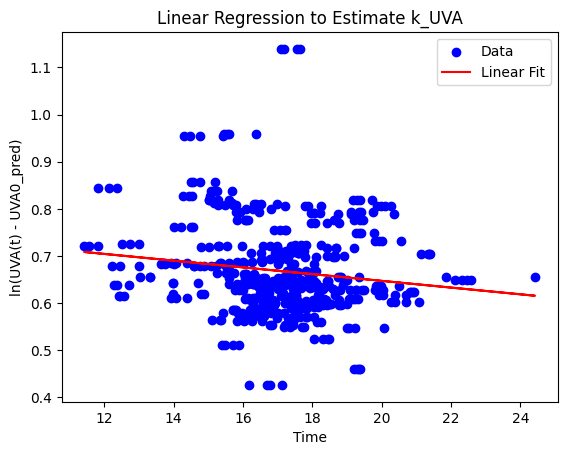

In [ ]:
#file_path = 'Ozoninput.xlsx'
#Ozoninput = pd.read_excel(file_path)
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/uvmodel.ipynb"
k_UVA, Ozoninput = UVAdecayrate(Ozoninput)

# **Modeling Ozone concentration using the combined Ozone model**

## **Setting the dataset**

In [ ]:
file_path = 'PIMSLIMSfinal2020-2025.xlsx'
#file_path = 'Ozoninput_2.xlsx'
Ozoninput = pd.read_excel(file_path)

In [ ]:
before = len(Ozoninput)
Ozoninput = Ozoninput.dropna(subset=['CT_All'])
after = len(Ozoninput)
print(f"Dropped {before - after} rows with NaN in the selected column.")
print(f"Remaining rows: {after}")

Dropped 0 rows with NaN in the selected column.
Remaining rows: 518


In [ ]:
output_path = 'Ozoninput_2.xlsx'
Ozoninput.to_excel(output_path, index=False)

## **Feature selection, Pearson and Spearman correlations, and SOMs**

Available columns in the dataset:
1. Date
2. hour
3. month
4. Chamber
5. WaterTemperature
6. RFUV
7. RFTurbidity
8. FlowRate
9. Ozonedosage
10. Volume
11. Residencetime
12. WaterTemperature_1
13. WaterTemperature_2
14. WaterTemperature_3
15. WaterTemperature_4
16. WaterTemperature_5
17. RFturbidity_1
18. RFturbidity_2
19. RFturbidity_3
20. RFturbidity_4
21. RFturbidity_5
22. FlowRate_1
23. FlowRate_2
24. FlowRate_3
25. FlowRate_4
26. FlowRate_5
27. Ozonedosage_1
28. Ozonedosage_2
29. Ozonedosage_3
30. Ozonedosage_4
31. Ozonedosage_5
32. T_2
33. T_3
34. T_4
35. T_5
36. T_6
37. T_7
38. T_8
39. T_9
40. T_10
41. CT_1
42. CT_2
43. CT_3
44. CT_4
45. CT_5
46. CT_6
47. CT_7
48. CT_8
49. CT_9
50. CT_All
51. O3_2
52. O3_3
53. O3_4
54. O3_5
55. O3_6
56. O3_7
57. O3_8
58. O3_9
59. O3_10
60. Ko3
61. UVA0_pred
62. OzoneYield
63. Bromate_RapidSandfiltration_inlet
64. Bromide_Ozonation_inlet
65. Campylobacter _Rapid Sandfiltration_inlet
66. Coliformbacteria 37C_Ozonation_inlet
67. Coliformbacteria 37C

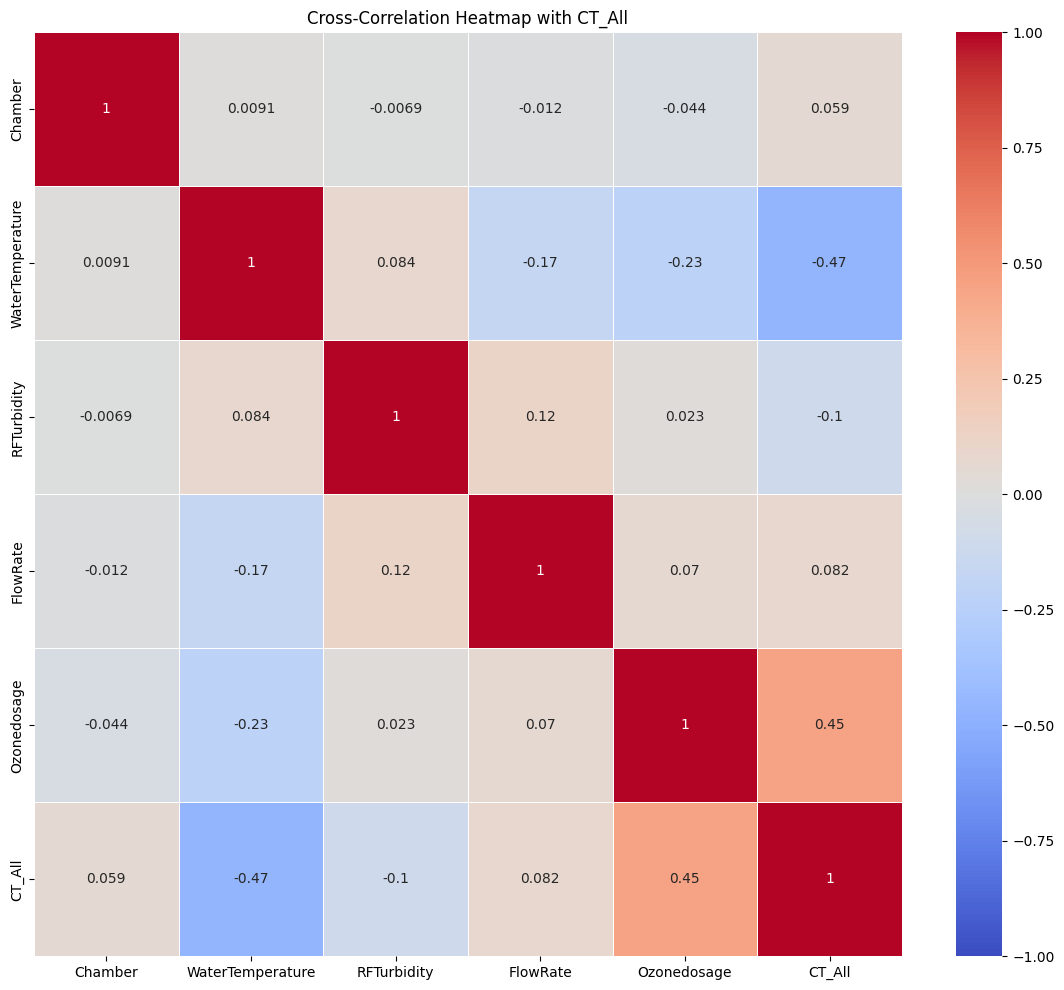


Pearson Correlation:
CT_All              1.000000
Ozonedosage         0.452481
FlowRate            0.082361
Chamber             0.059306
RFTurbidity        -0.104058
WaterTemperature   -0.465647
Name: CT_All, dtype: float64


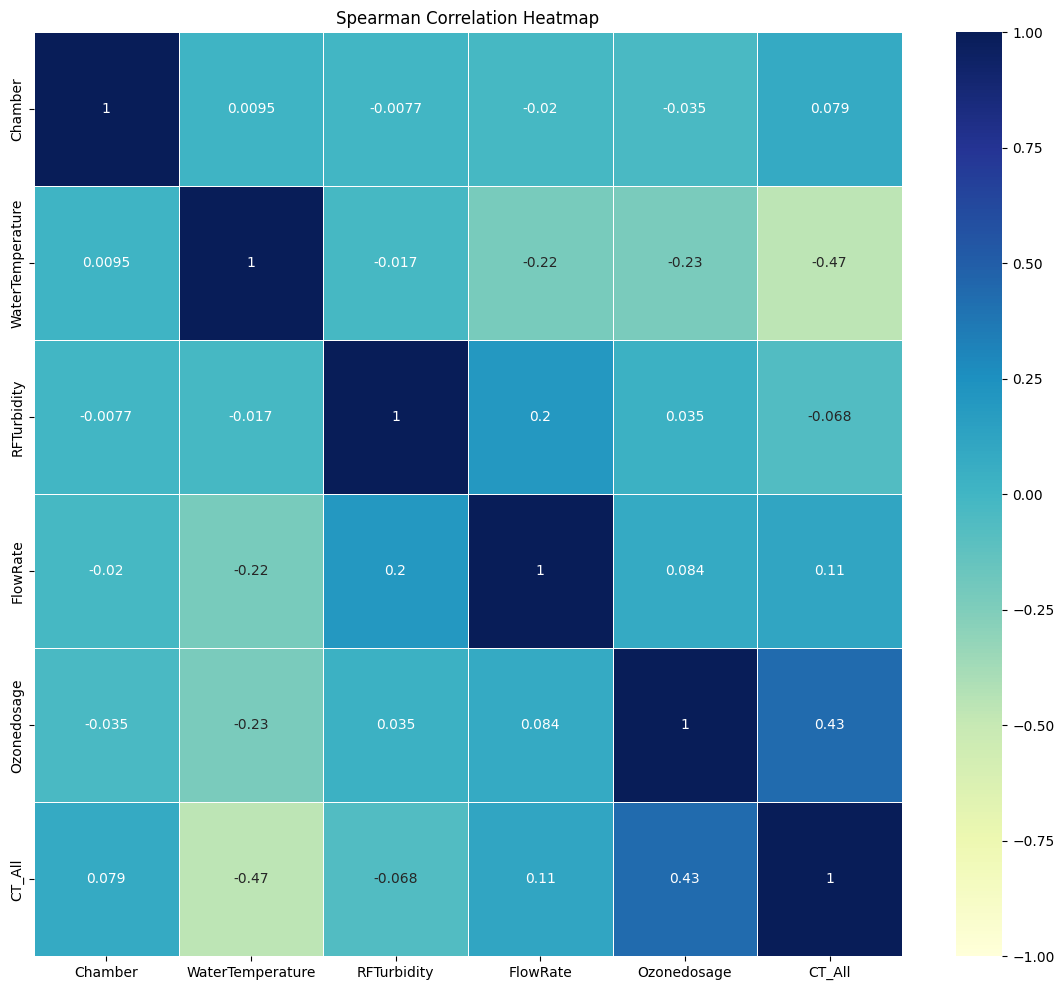


Spearman Correlation:
CT_All              1.000000
Ozonedosage         0.432759
FlowRate            0.114426
Chamber             0.078820
RFTurbidity        -0.068173
WaterTemperature   -0.468722
Name: CT_All, dtype: float64

Greedy Feature Selection (SFS with Linear Regression):
Selected Features: ['WaterTemperature', 'RFTurbidity', 'FlowRate', 'Ozonedosage']

Mutual Information:
WaterTemperature    0.214758
Ozonedosage         0.146537
RFTurbidity         0.091994
FlowRate            0.045704
Chamber             0.002150
dtype: float64

L1 Regularization (LassoCV):
WaterTemperature    0.122477
Ozonedosage         0.115083
Chamber             0.000000
RFTurbidity         0.000000
FlowRate            0.000000
dtype: float64

Permutation Importance (RandomForest):
WaterTemperature    0.787744
Ozonedosage         0.632412
Chamber             0.167843
FlowRate            0.113779
RFTurbidity         0.101713
dtype: float64


In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/ozonemodel.ipynb"
X,y,input_features, target_variable,models_info = plot_cross_correlation(Ozoninput)

## **Select the Co3 inputs and calculate average Ko3**

In [ ]:
CO3_t=Ozoninput.iloc[:,50:59]
#CO3_t=Ozoninput.iloc[:,62:70]
Ko3=np.mean(Ozoninput['Ko3'])
T=Ozoninput.iloc[:,31:40]
#T=Ozoninput.iloc[:,43:51]
k_UVA = 0

## **Ozone exposure model**


Select a model:
1. Random Forest
2. XGBoost
3. Multi ensemble Random Forest
4. Multi ensemble XGBoost
5. Random Forest - XGBoost combination
6. Random Forest - Combination of 8 top-8 most important features (as per feature importance methods)
7. XGBoost - Combination of 8 top-8 most important features (as per feature importance methods)
8. Random Forest & XGBoost - Combination of 8 top-8 most important features (as per feature importance methods)
9. Gradient Boosting
10. AdaBoost
11. LightGBM
12. Random Forrest - XGBoost - GBoost ensemble of up to 18 models
13. Physics-Informed MLP
14. XTC - hybrid model
15. Ensemble of Best Models - Weighted
Best Gradient Boosting Hyperparameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.5}
✅ Best Gradient Boosting model saved to: /content/drive/My Drive/Colab Notebooks/Ozonation model/gb_test_5.pkl

Model Performance:
MAE: 0.1846
MSE: 0.0583
RMSE: 0.2414
Scatter Index: 0.3697
R²: 0.7410
Kling - Gupta - Efficiency (KGE): 0.0000
Set th

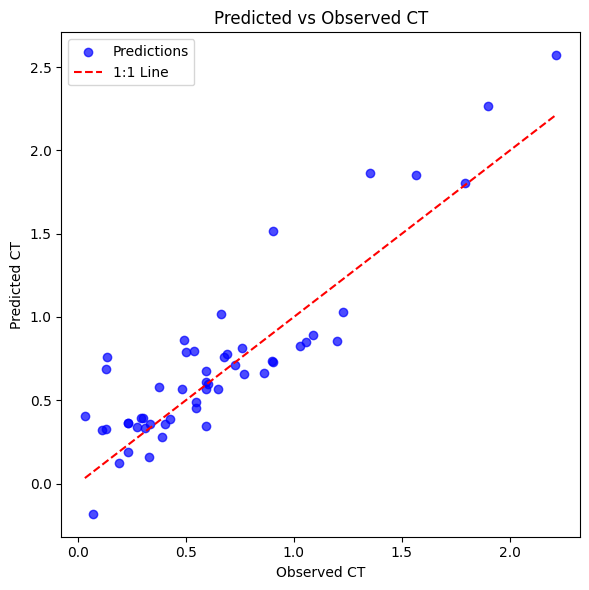

GBoost - Feature Importance


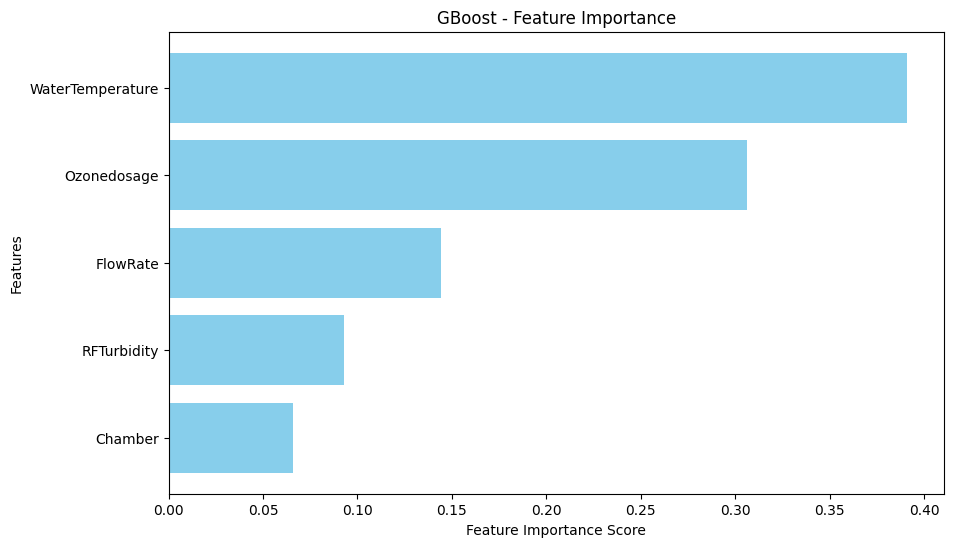

GBoost - SHAP Summary


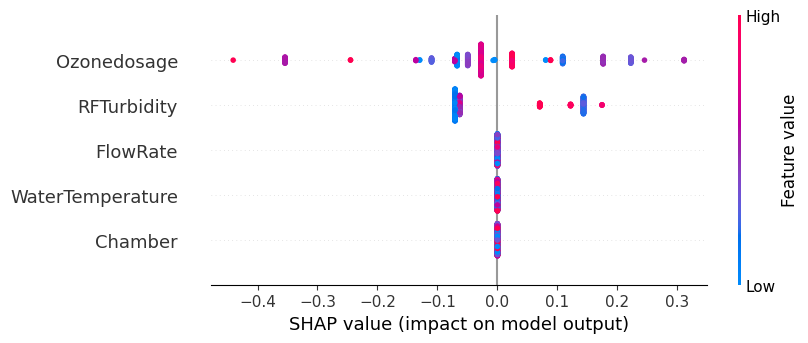

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/ozonemodel.ipynb"
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/X-TFCmodel.ipynb"
Vol = [68.4, 71.08, 72.96, 96.9, 145.82, 152.15, 327.21, 360.43, 537.15, 573.86]
voldiff = np.diff(Vol).reshape(-1, 1)
#XTC_model, CT_pred_xtfc, CT_pred_hybrid, Xtr_hybrid, Xte_hybrid,k_train,hybrid_features= X_TFC_CT_compartment_model(X,y,T,voldiff)
best_model, mae, mse, rmse, r2, si, kge, y_test, y_pred = predict_ozone_exposure(X, y, input_features, target_variable, k_UVA,CO3_t,Ko3,T, models_info,voldiff)

## **Daily prediction graphs and comparison with calculated estimations and risks limits**

In [ ]:
file_path = 'PIMSLIMSfinal2020-2025.xlsx'
ozoneprint = pd.read_excel(file_path)

Set the start date in the format of 2024-10-01):2023-11-01
Set the start hour (0-23):12
Set the end date in the format of 2024-10-01):2023-11-30
Set the end hour (0-23):12
Set the chamber (1-4):2
Predicting using simple model: GB_test_5_v2_42.pkl

--- Sensitivity Analysis ---
Available features: ['Chamber', 'WaterTemperature', 'RFTurbidity', 'FlowRate', 'Ozonedosage']
Which feature would you like to vary? Ozonedosage
Enter percentage changes separated by commas (e.g. -10, 10, 20): -5,-10,-15


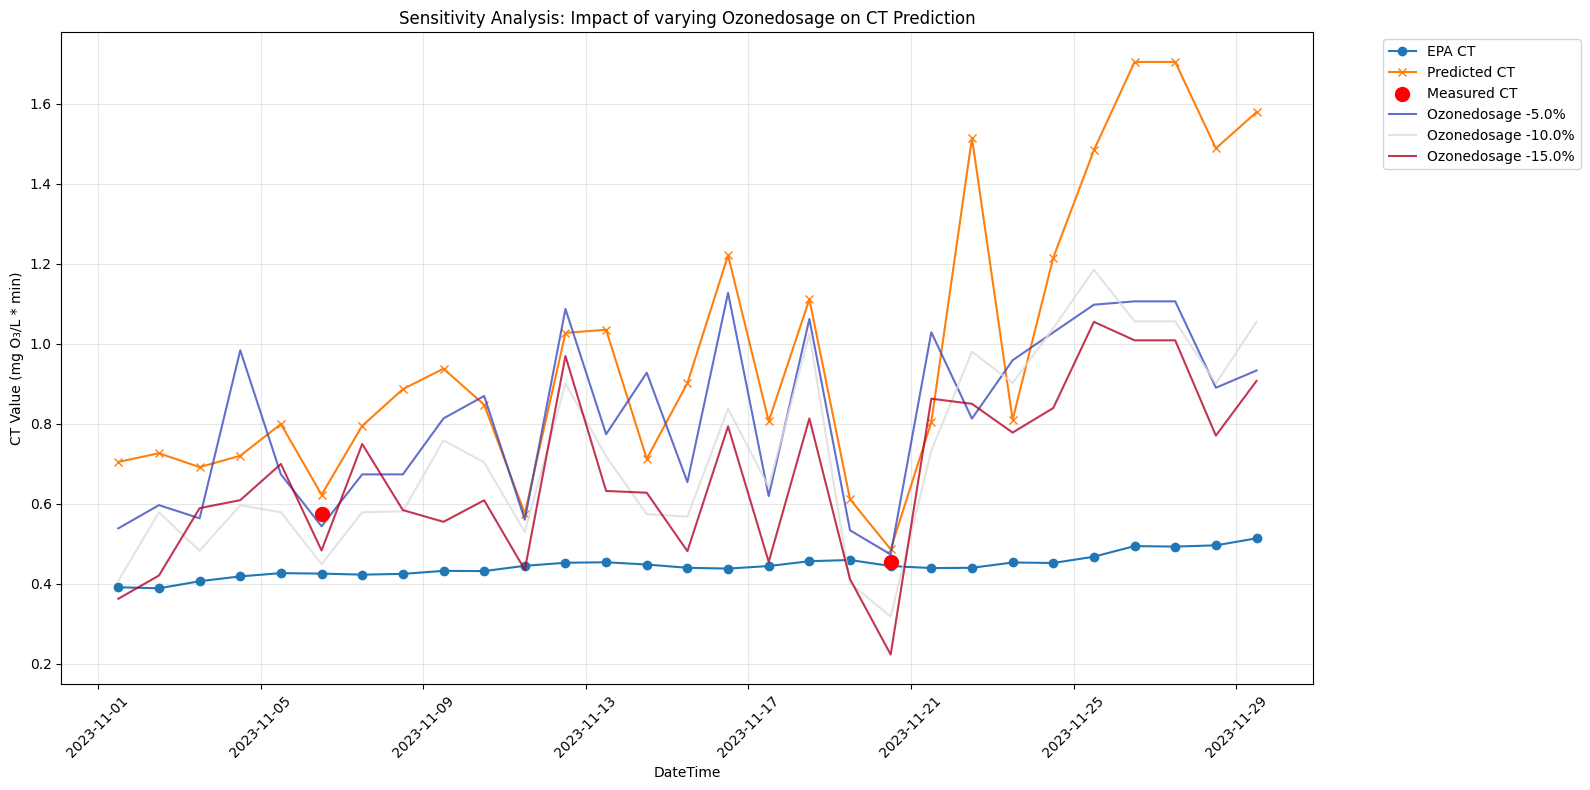

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/predgraphs.ipynb"
filtered_df, y_pred = ozoneplots(ozoneprint)

# **Modeling Bromate concentration in the ozonation outlet**

## **Replace or remove NAN values of the selected parameters**

In [ ]:
file_path = 'PIMSLIMSfinal2020-2025.xlsx'
bromate = pd.read_excel(file_path)
#Convert and prepare dataset
mask = bromate['Bromide_Ozonation_inlet'].notna() & bromate['Bromate_WTP_outlet'].isna()
bromate.loc[mask, 'Bromate_WTP_outlet'] = bromate['Bromate_WTP_outlet'].bfill()
before = len(bromate)
bromateinput = bromate.dropna(subset=['Bromide_Ozonation_inlet'])
after = len(bromateinput)
print(f"Dropped {before - after} rows with NaN in the selected column.")
print(f"Remaining rows: {after}")
output_path = 'Bromateinput.xlsx'
bromateinput.to_excel(output_path, index=False)

Dropped 172641 rows with NaN in the selected column.
Remaining rows: 1032


In [ ]:
input_path = 'Bromateinput.xlsx'
bromateinput = pd.read_excel(input_path)

### **Replace CT NAN values with predicted CT values**

In [ ]:
missing_mask = bromateinput['CT_All'].isna()
input_features = ['hour', 'month', 'Chamber', 'WaterTemperature', 'RFTurbidity', 'FlowRate', 'Ozonedosage', 'Residencetime']
X_missing = bromateinput.loc[missing_mask, input_features]
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/bromateadditionalmodel.ipynb"
predictions = ctpredict(X_missing)
print(f"Rows to fill: {missing_mask.sum()}")
print(f"Predictions received: {len(predictions)}")
bromateinput.loc[missing_mask, 'CT_All'] = predictions

Predicting using simple model: GB_test_5_v2_42.pkl
Rows to fill: 824
Predictions received: 824


## **Feature selection, Pearson and Spearman correlations, and SOMs**

Available columns in the dataset:
1. Date
2. hour
3. month
4. Chamber
5. WaterTemperature
6. RFUV
7. RFTurbidity
8. FlowRate
9. Ozonedosage
10. Volume
11. Residencetime
12. WaterTemperature_1
13. WaterTemperature_2
14. WaterTemperature_3
15. WaterTemperature_4
16. WaterTemperature_5
17. RFturbidity_1
18. RFturbidity_2
19. RFturbidity_3
20. RFturbidity_4
21. RFturbidity_5
22. FlowRate_1
23. FlowRate_2
24. FlowRate_3
25. FlowRate_4
26. FlowRate_5
27. Ozonedosage_1
28. Ozonedosage_2
29. Ozonedosage_3
30. Ozonedosage_4
31. Ozonedosage_5
32. T_2
33. T_3
34. T_4
35. T_5
36. T_6
37. T_7
38. T_8
39. T_9
40. T_10
41. CT_1
42. CT_2
43. CT_3
44. CT_4
45. CT_5
46. CT_6
47. CT_7
48. CT_8
49. CT_9
50. CT_All
51. O3_2
52. O3_3
53. O3_4
54. O3_5
55. O3_6
56. O3_7
57. O3_8
58. O3_9
59. O3_10
60. Ko3
61. UVA0_pred
62. OzoneYield
63. Bromate_RapidSandfiltration_inlet
64. Bromide_Ozonation_inlet
65. Campylobacter _Rapid Sandfiltration_inlet
66. Coliformbacteria 37C_Ozonation_inlet
67. Coliformbacteria 37C

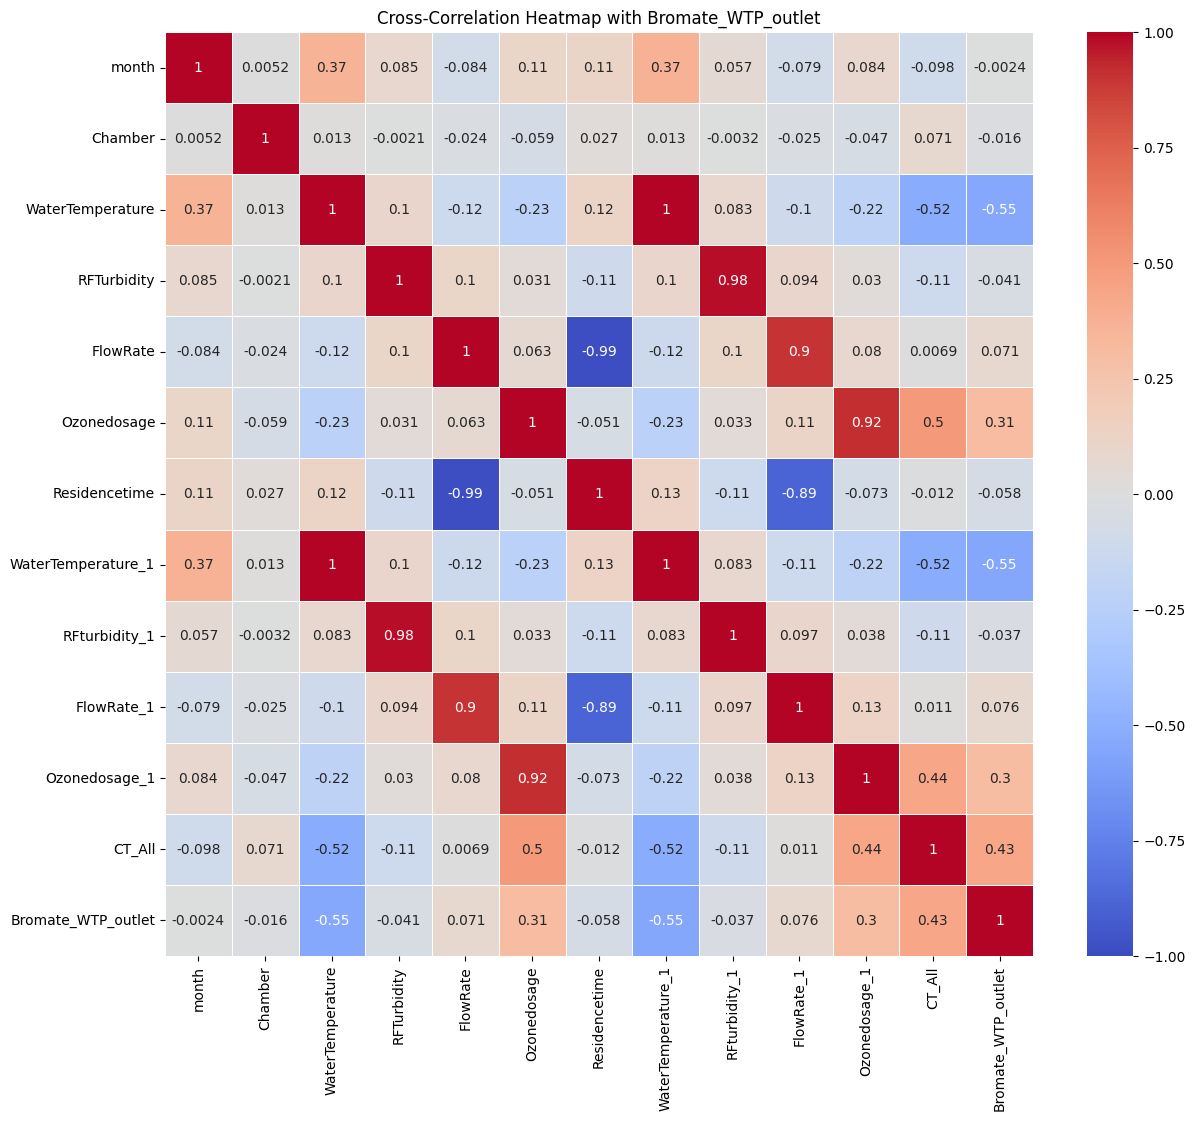


Pearson Correlation:
Bromate_WTP_outlet    1.000000
CT_All                0.434166
Ozonedosage           0.309900
Ozonedosage_1         0.298486
FlowRate_1            0.076145
FlowRate              0.071402
month                -0.002370
Chamber              -0.016145
RFturbidity_1        -0.037061
RFTurbidity          -0.040815
Residencetime        -0.057958
WaterTemperature     -0.546830
WaterTemperature_1   -0.547169
Name: Bromate_WTP_outlet, dtype: float64


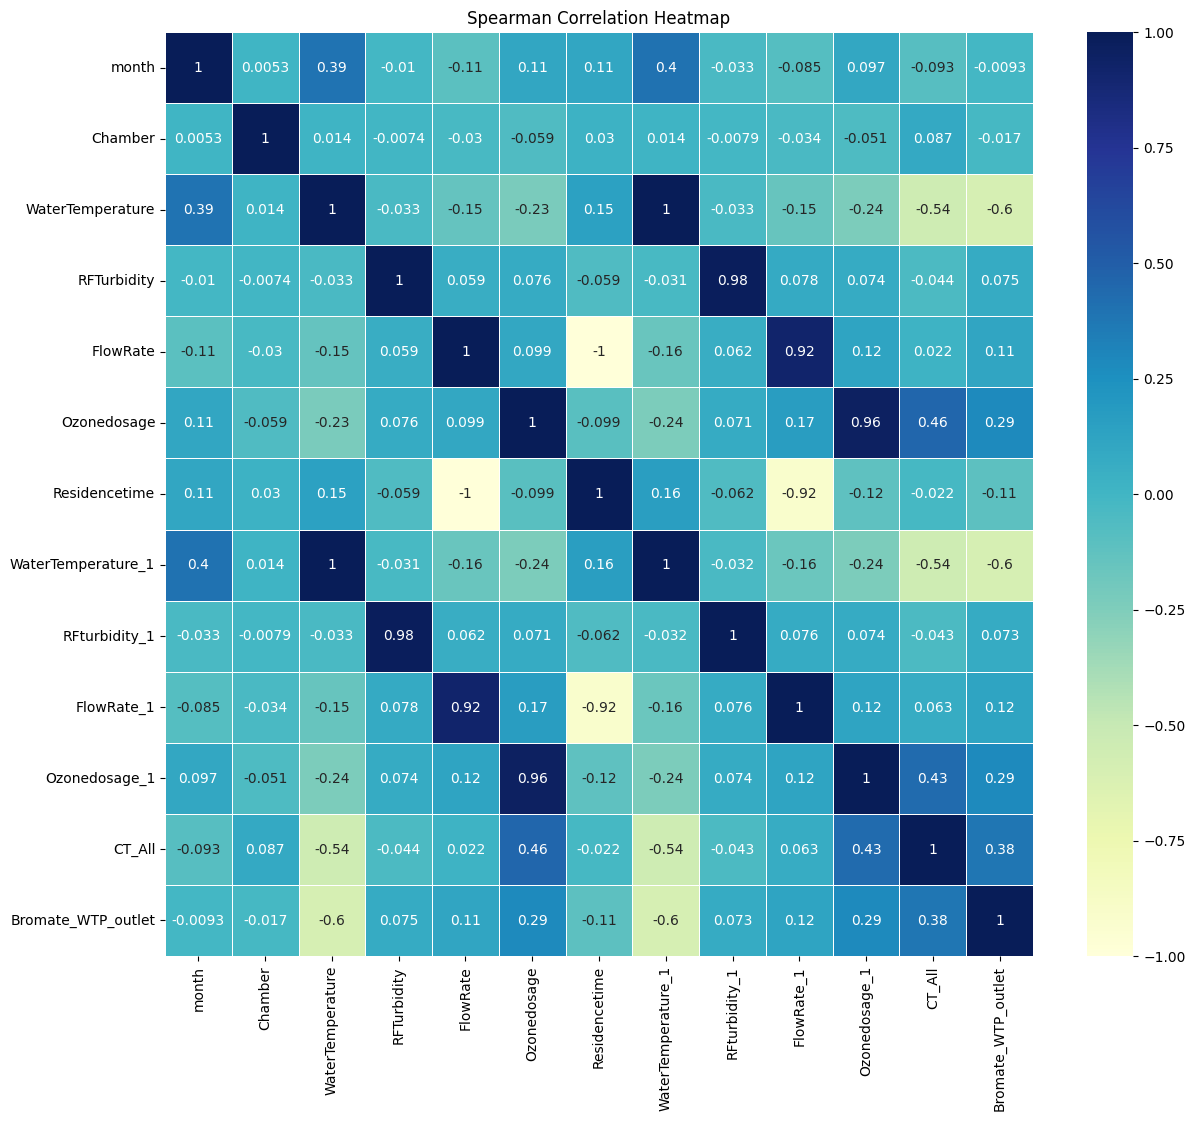


Spearman Correlation:
Bromate_WTP_outlet    1.000000
CT_All                0.379692
Ozonedosage           0.287079
Ozonedosage_1         0.285007
FlowRate_1            0.118584
FlowRate              0.111384
RFTurbidity           0.074512
RFturbidity_1         0.073068
month                -0.009271
Chamber              -0.016837
Residencetime        -0.111384
WaterTemperature_1   -0.600736
WaterTemperature     -0.601328
Name: Bromate_WTP_outlet, dtype: float64

Greedy Feature Selection (SFS with Linear Regression):
Selected Features: ['month', 'Chamber', 'WaterTemperature', 'RFTurbidity', 'FlowRate', 'Residencetime', 'WaterTemperature_1', 'RFturbidity_1']

Mutual Information:
WaterTemperature_1    4.260718
WaterTemperature      4.244895
RFTurbidity           4.206994
RFturbidity_1         4.089392
month                 1.665894
FlowRate              0.302250
FlowRate_1            0.293958
Residencetime         0.283223
CT_All                0.143204
Ozonedosage_1         0.140855
Ozo

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/ozonemodel.ipynb"
X,y,input_features, target_variable,models_info = plot_cross_correlation(bromateinput)

## **Calibrate K values for von Gunten model**

In [ ]:
CT = bromateinput['CT_All'].values
ozone_dosage = bromateinput['Ozonedosage'].values
bromate_measured = bromateinput['Bromate_WTP_outlet'].values
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/bromateadditionalmodel.ipynb"
k_calibrated, F_calibrated = k_calibrate(CT,ozone_dosage,bromate_measured)

Calibrated k: 0.6940807478903999, Calibrated F: 1.5876940255630374


## **Bromate in the ozonation outlet**


Select a model:
1. Random Forest
2. XGBoost
3. Gradient Boosting
4. AdaBoost
5. LightGBM
6. Physics-Informed MLP
7. van Gunten model
Best AdaBoosting Hyperparameters: {'n_estimators': 1000, 'learning_rate': 0.1, 'estimator__max_depth': 10}
✅ Best AdaBoost model saved to: /content/drive/My Drive/Colab Notebooks/Ozonation model/fffggh

Model Performance:
MAE: 0.0482
MSE: 0.0082
RMSE: 0.0905
Scatter Index: 0.0553
R²: 0.9865


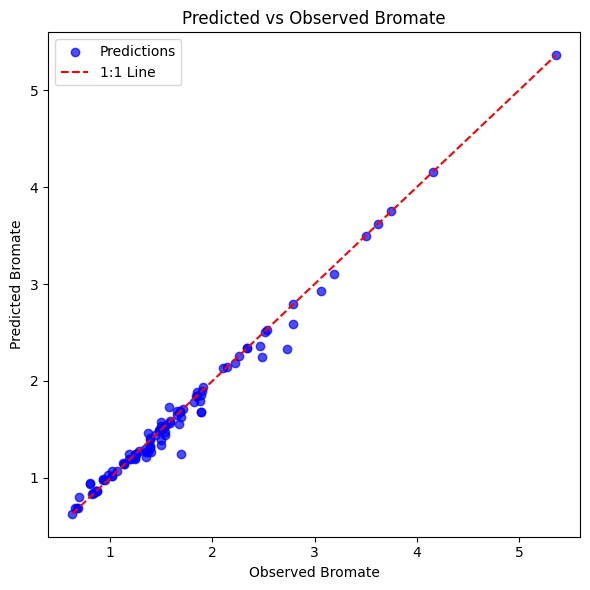

AdaBoost - Feature Importance


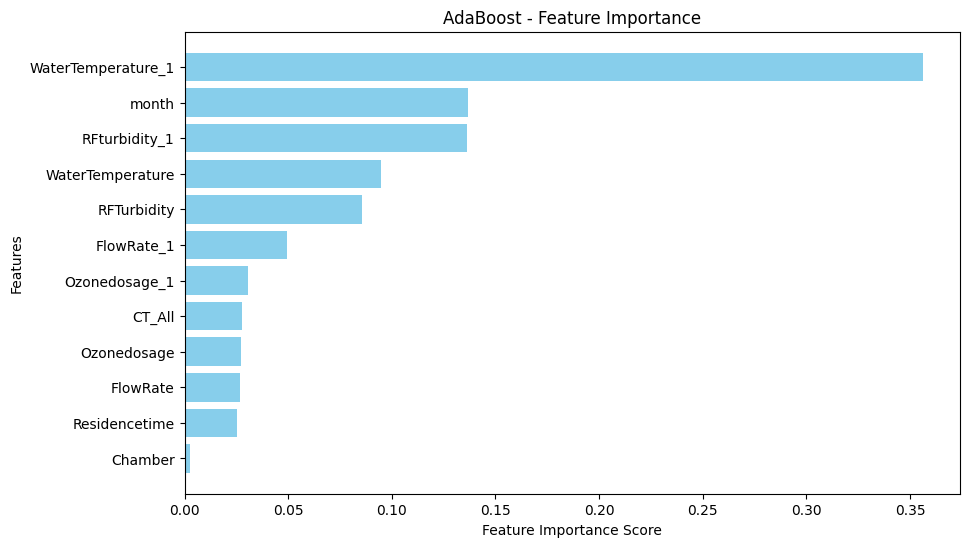

AdaBoost - SHAP Summary
AdaBoost - SHAP Summary


  0%|          | 0/100 [00:00<?, ?it/s]

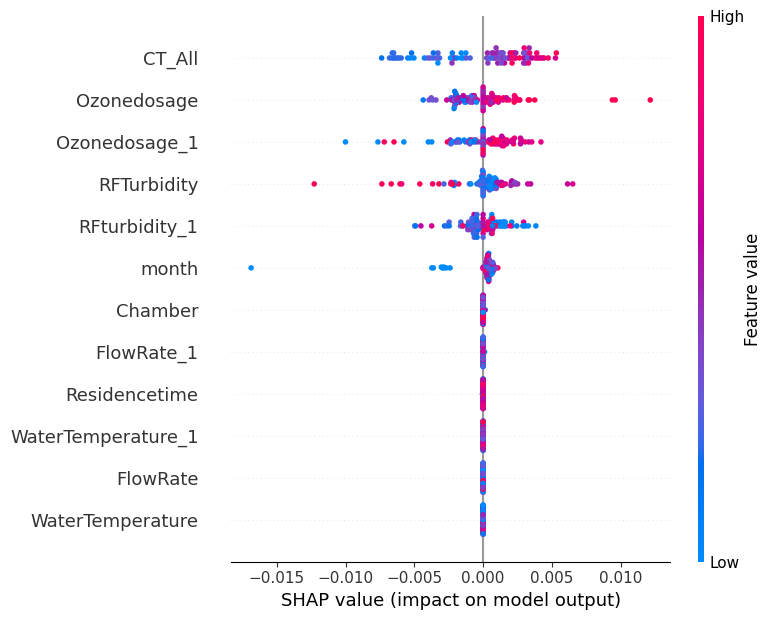

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/bromateadditionalmodel.ipynb"
best_model, mae, mse, rmse, r2, si, y_test, y_pred = predict_bromate_outlet(X, y, input_features, target_variable, k_calibrated, F_calibrated, models_info)

### **Replace CT NAN values with predicted CT values**

In [ ]:
missing_mask = bromateprint['CT_All'].isna()
input_features = ['hour', 'month', 'Chamber', 'WaterTemperature', 'RFTurbidity', 'FlowRate', 'Ozonedosage', 'Residencetime']
X_missing = bromateprint.loc[missing_mask, input_features]
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/bromateadditionalmodel.ipynb"
predictions = ctpredict(X_missing)
bromateprint.loc[missing_mask, 'CT_All'] = predictions

Predicting using simple model: GB_test_5_v2_42.pkl


## **Daily prediction graphs and comparison with calculated estimations and risks limits**

### **Load full dataset**

In [ ]:
file_path = 'PIMSLIMSfinal2020-2025.xlsx'
bromateprint = pd.read_excel(file_path)
bromateprint = bromateprint.drop(bromateprint.index[-1])

### **Replace CT NAN values with predicted CT values**

In [ ]:
missing_mask = bromateprint['CT_All'].isna()
input_features = ['hour', 'month', 'Chamber', 'WaterTemperature', 'RFTurbidity', 'FlowRate', 'Ozonedosage', 'Residencetime']
X_missing = bromateprint.loc[missing_mask, input_features]
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/bromateadditionalmodel.ipynb"
predictions = ctpredict(X_missing)
bromateprint.loc[missing_mask, 'CT_All'] = predictions

Predicting using simple model: GB_test_5_v2_42.pkl


### **Select period and chamber, predict outputs and plot results**

Set the start date in the format of 2024-10-01):2023-11-01
Set the start hour (0-23):12
Set the end date in the format of 2024-10-01):2023-11-30
Set the end hour (0-23):12
Set the chamber (1-4):2
✅ All models and scalers loaded successfully.

--- Bromate Sensitivity Analysis ---
Enter Ozonedosage change % (e.g., 20 or -15): -10
Enter 1 hour timelagged Ozonedosage change % (e.g., 20 or -15): -10
Recalculating CT for new dosage...
Predicting using simple model: GB_test_5_v2_42.pkl


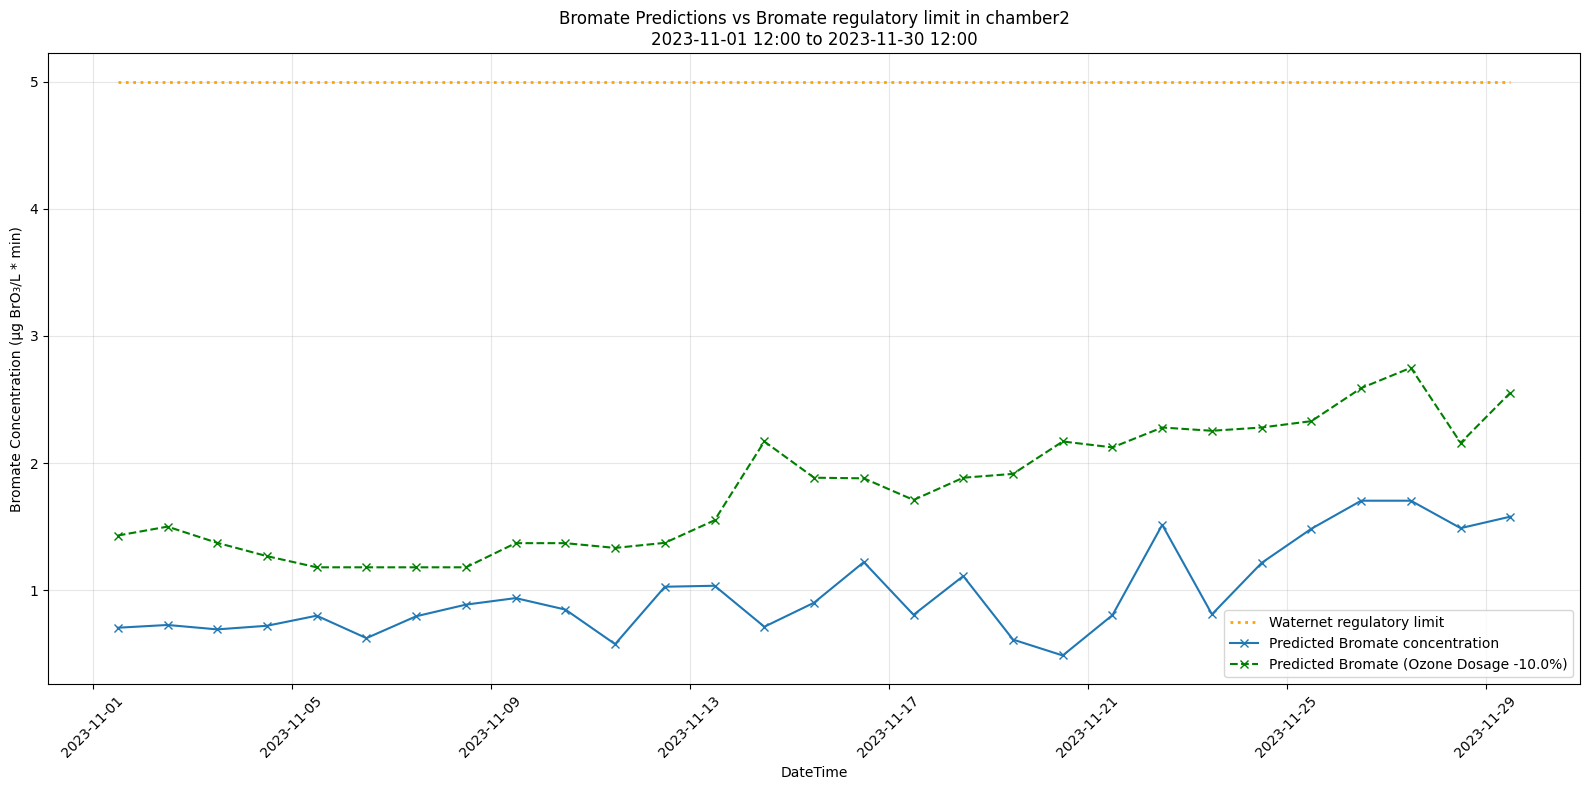

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/bromateadditionalmodel.ipynb"
filtered_df,y_pred = bromateplots(bromateprint)

# **Modeling the coliform bacteria in the ozonation outlet**

## **Calculate logarithmic removal ln(N/No)**


In [ ]:
mask = Ozoninput['Coliformbacteria 37C_Ozonation_inlet'].notna() & Ozoninput['Coliformbacteria 37C_Ozonation_outlet'].notna()
# Initialize column with NaN
Ozoninput['Coliform_log_removal'] = np.nan
Ozoninput['Ozone_logmean_concentration'] = np.nan
Ozoninput['K_Hom_estimation'] = np.nan

# Calculate log(col1/col2) only where both values exist
Ozoninput.loc[mask, 'Coliform_log_removal'] = np.log10(Ozoninput.loc[mask, 'Coliformbacteria 37C_Ozonation_outlet'] / Ozoninput.loc[mask, 'Coliformbacteria 37C_Ozonation_inlet'])
Ozoninput.loc[mask, 'Ozone_logmean_concentration'] = (Ozoninput.loc[mask, 'Ozonedosage'] - 0.012)/ np.log10(Ozoninput.loc[mask, 'Ozonedosage'] / 0.012)
Ozoninput.loc[mask,'K_Hom_observed'] = - Ozoninput.loc[mask, 'Coliform_log_removal'] /  (Ozoninput.loc[mask, 'Ozone_logmean_concentration'] * Ozoninput.loc[mask, 'Residencetime']**2)

In [ ]:
Ozoninput.to_excel(file_path, index=False)

## **Replace or remove NAN values of the selected parameters**


In [ ]:
file_path = 'PIMSLIMSfinal2020-2025.xlsx'
colbacteria = pd.read_excel(file_path)
#Convert and prepare dataset
mask = colbacteria['Coliformbacteria 37C_Ozonation_inlet'].notna() & colbacteria['Coliformbacteria 37C_Ozonation_outlet'].notna()
before = len(colbacteria)
colbacteriainput = colbacteria.dropna(subset=['Coliformbacteria 37C_Ozonation_inlet', 'Coliformbacteria 37C_Ozonation_outlet'])
after = len(colbacteriainput)
print(f"Dropped {before - after} rows with NaN in the selected column.")
print(f"Remaining rows: {after}")
output_path = 'Colbacteriainput.xlsx'
colbacteriainput.to_excel(output_path, index=False)

Dropped 173357 rows with NaN in the selected column.
Remaining rows: 315


In [ ]:
input_path = 'Colbacteriainput.xlsx'
colbacteriainput = pd.read_excel(input_path)

### **Replace CT NAN values with predicted CT values**

In [ ]:
missing_mask = colbacteriainput['CT_All'].isna()
input_features = ['hour', 'month', 'Chamber', 'WaterTemperature', 'RFTurbidity', 'FlowRate', 'Ozonedosage', 'Residencetime']
X_missing = colbacteriainput.loc[missing_mask, input_features]
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/Khomandlogremovalmodel.ipynb"
predictions = ctpredict(X_missing)
colbacteriainput.loc[missing_mask, 'CT_All'] = predictions

Predicting using simple model: GB_test_5_v2_42.pkl


## **Feature selection, Pearson and Spearman correlations, and SOMs**

Available columns in the dataset:
1. Date
2. hour
3. month
4. Chamber
5. WaterTemperature
6. RFUV
7. RFTurbidity
8. FlowRate
9. Ozonedosage
10. Volume
11. Residencetime
12. WaterTemperature_1
13. WaterTemperature_2
14. WaterTemperature_3
15. WaterTemperature_4
16. WaterTemperature_5
17. RFturbidity_1
18. RFturbidity_2
19. RFturbidity_3
20. RFturbidity_4
21. RFturbidity_5
22. FlowRate_1
23. FlowRate_2
24. FlowRate_3
25. FlowRate_4
26. FlowRate_5
27. Ozonedosage_1
28. Ozonedosage_2
29. Ozonedosage_3
30. Ozonedosage_4
31. Ozonedosage_5
32. T_2
33. T_3
34. T_4
35. T_5
36. T_6
37. T_7
38. T_8
39. T_9
40. T_10
41. CT_1
42. CT_2
43. CT_3
44. CT_4
45. CT_5
46. CT_6
47. CT_7
48. CT_8
49. CT_9
50. CT_All
51. O3_2
52. O3_3
53. O3_4
54. O3_5
55. O3_6
56. O3_7
57. O3_8
58. O3_9
59. O3_10
60. Ko3
61. UVA0_pred
62. OzoneYield
63. Bromate_RapidSandfiltration_inlet
64. Bromide_Ozonation_inlet
65. Campylobacter _Rapid Sandfiltration_inlet
66. Coliformbacteria 37C_Ozonation_inlet
67. Coliformbacteria 37C

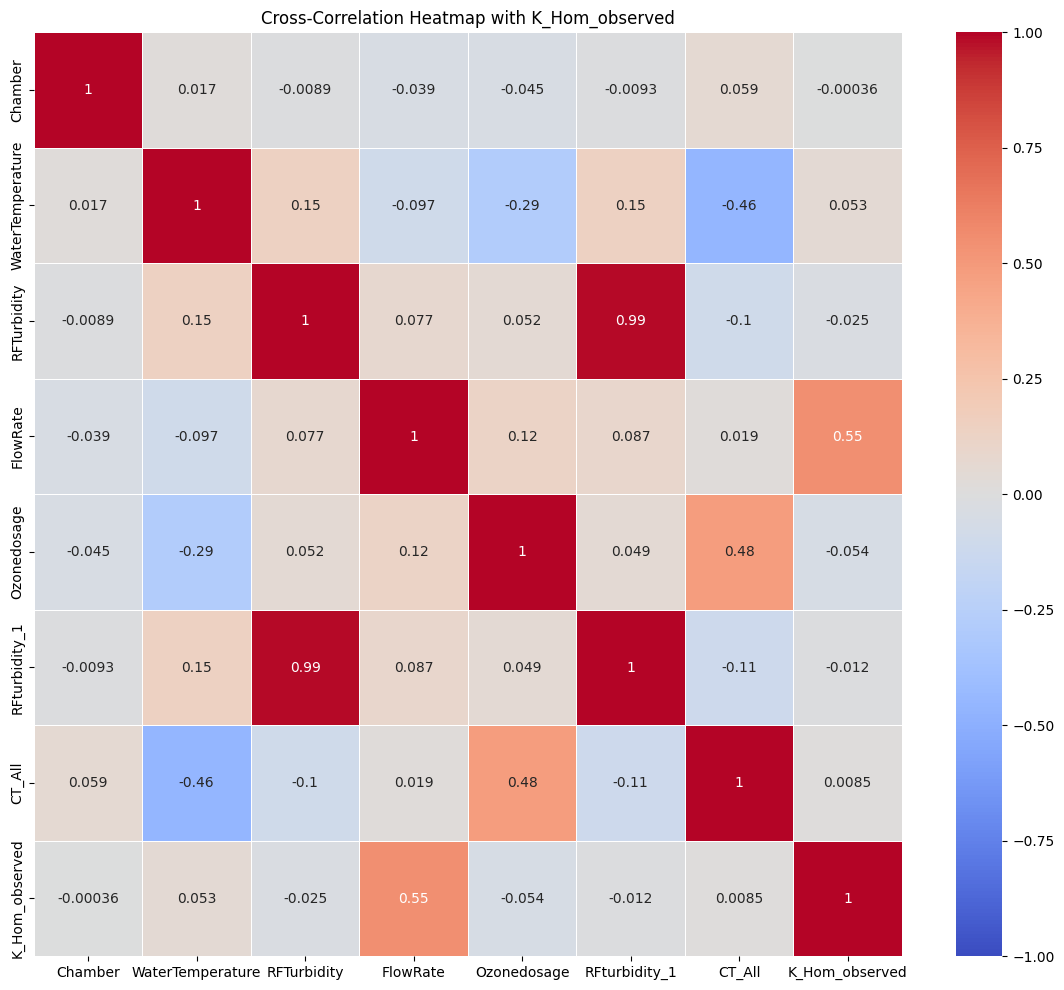


Pearson Correlation:
K_Hom_observed      1.000000
FlowRate            0.554019
WaterTemperature    0.053390
CT_All              0.008501
Chamber            -0.000358
RFturbidity_1      -0.012366
RFTurbidity        -0.025308
Ozonedosage        -0.053546
Name: K_Hom_observed, dtype: float64


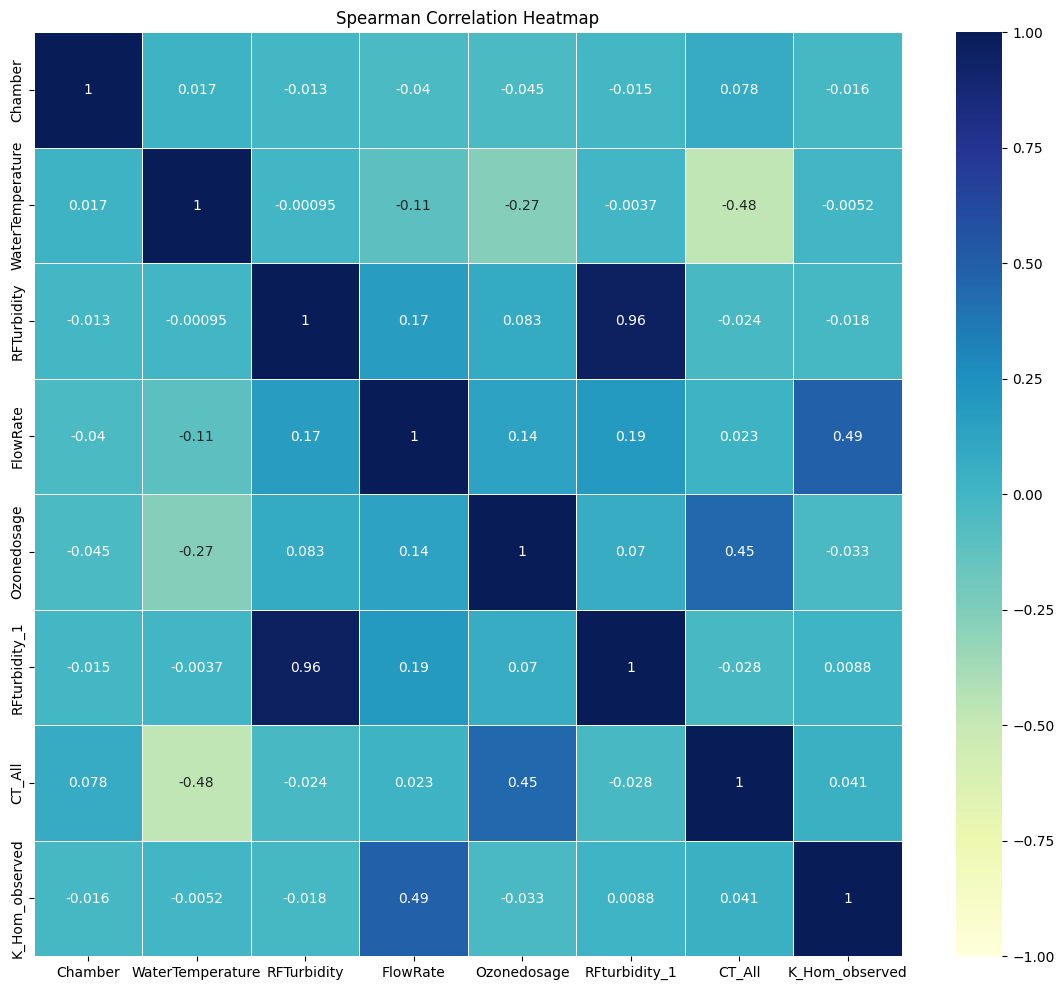


Spearman Correlation:
K_Hom_observed      1.000000
FlowRate            0.486912
CT_All              0.040808
RFturbidity_1       0.008817
WaterTemperature   -0.005161
Chamber            -0.016290
RFTurbidity        -0.017885
Ozonedosage        -0.032859
Name: K_Hom_observed, dtype: float64

Greedy Feature Selection (SFS with Linear Regression):
Selected Features: ['Chamber', 'WaterTemperature', 'RFTurbidity', 'FlowRate', 'Ozonedosage', 'CT_All']

Mutual Information:
WaterTemperature    0.604513
RFTurbidity         0.602588
RFturbidity_1       0.583035
FlowRate            0.456427
Ozonedosage         0.121710
CT_All              0.047595
Chamber             0.000000
dtype: float64

L1 Regularization (LassoCV):
FlowRate            0.003583
WaterTemperature    0.000000
Chamber             0.000000
RFTurbidity         0.000000
Ozonedosage         0.000000
RFturbidity_1       0.000000
CT_All              0.000000
dtype: float64

Permutation Importance (RandomForest):
FlowRate            0.

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/ozonemodel.ipynb"
X,y,input_features, target_variable,models_info = plot_cross_correlation(colbacteriainput)

## **Log removal in the ozonation process**


Select a model:
1. Random Forest
2. XGBoost
3. Gradient Boosting
4. AdaBoost
5. LightGBM
6. Physics-Informed MLP
7. Best 4 models weighted
Enter the number corresponding to your choice:4
Set the testing size(e.g. 0.1 = 10% for testing):0.1
Set the random state:42
Set the folder name:dddddd
Best AdaBoosting Hyperparameters: {'n_estimators': 1000, 'learning_rate': 0.1, 'estimator__max_depth': 10}
Set the AdaBoost model name:fgggdhh
✅ Best AdaBoost model saved to: /content/drive/My Drive/Colab Notebooks/Ozonation model/fgggdhh

Model Performance:
Std obs: 0.0091
Std pred: 0.0086
R crosscor: 0.9728
Beta: 1.0214
gamma: 0.9227
Kling - Gupta - Efficiency (KGE): 0.9153

Performance for predicting inactivation rate k:
MAE: 0.0017
MSE: 0.0000
RMSE: 0.0022
Scatter Index: 0.1092
R²: 0.9433
Kling Gupta Efficiency: 0.9153

Model Performance:
Std obs: 0.7342
Std pred: 0.6829
R crosscor: 0.9583
Beta: 1.0270
gamma: 0.9057
Kling - Gupta - Efficiency (KGE): 0.8934

Performance for predicting log removal

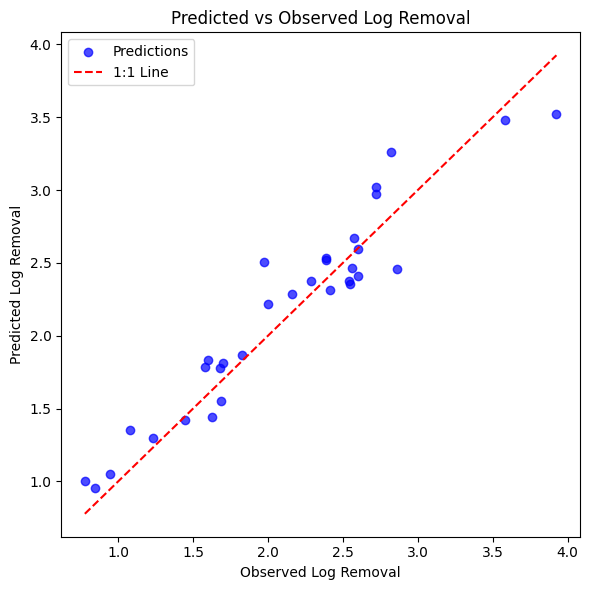

AdaBoost - Feature Importance


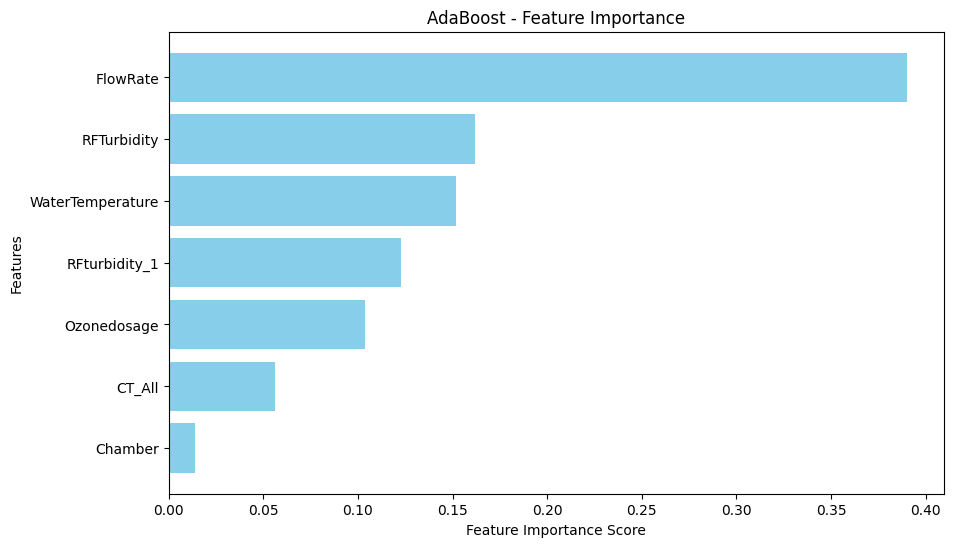

AdaBoost - SHAP Summary


  0%|          | 0/100 [00:00<?, ?it/s]

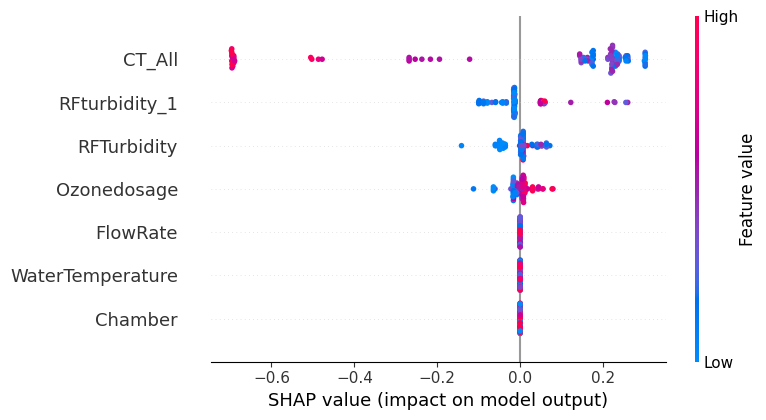

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/Khomandlogremovalmodel.ipynb"
log_removal_observed= colbacteriainput['Coliform_log_removal']
Clog=colbacteriainput['Ozone_logmean_concentration']
time=colbacteriainput['Residencetime']
best_model, mae, mse, rmse, r2, si, y_test, y_pred = predict_logremoval_outlet(X, y, input_features, target_variable, models_info,log_removal_observed,Clog,time)

## **Daily prediction graphs and comparison with calculated estimations and risks limits**

### **Load full dataset**

In [ ]:
file_path = 'PIMSLIMSfinal2020-2025.xlsx'
colprint = pd.read_excel(file_path)
colprint = colprint.drop(colprint.index[-1])

### **Replace CT NAN values with predicted CT values**

In [ ]:
missing_mask = colprint['CT_All'].isna()
input_features = ['hour', 'month', 'Chamber', 'WaterTemperature', 'RFTurbidity', 'FlowRate', 'Ozonedosage', 'Residencetime']
X_missing = colprint.loc[missing_mask, input_features]
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/Khomandlogremovalmodel.ipynb"
predictions = ctpredict(X_missing)
colprint.loc[missing_mask, 'CT_All'] = predictions

Predicting using simple model: GB_test_5_v2_42.pkl


### **Select period and chamber, predict outputs and plot results**

Set the start date in the format of 2024-10-01):2023-11-01
Set the start hour (0-23):12
Set the end date in the format of 2024-10-01):2023-11-30
Set the end hour (0-23):12
Set the chamber (1-4):2
✅ All models and scalers loaded successfully.

--- Coliform Sensitivity Analysis ---
Enter Ozonedosage change % (e.g., 10 or -10): -10
Predicting using simple model: GB_test_5_v2_42.pkl


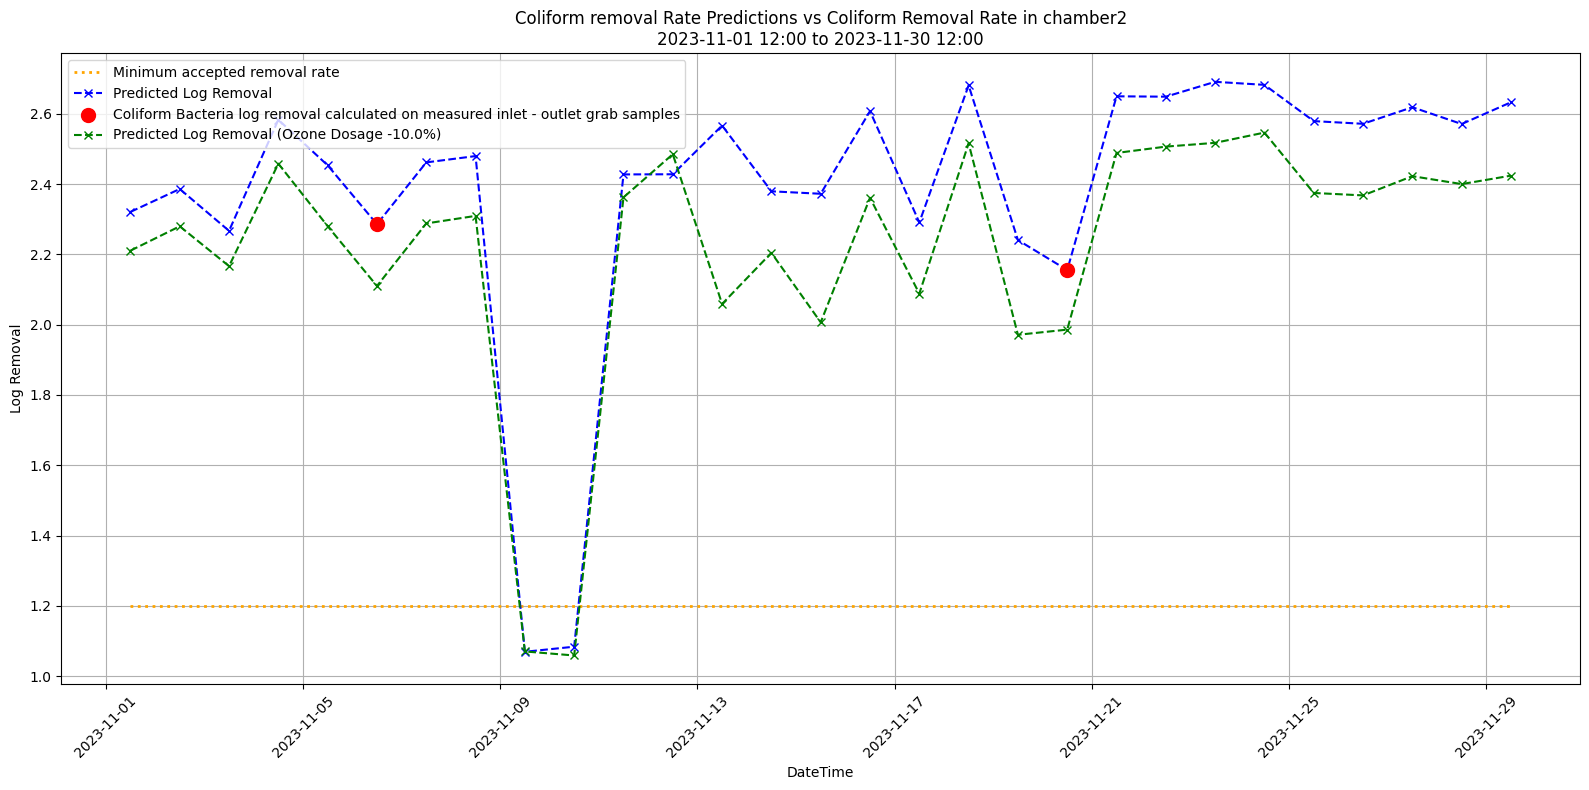

In [ ]:
%run "/content/drive/My Drive/Colab Notebooks/Ozonation model/Khomandlogremovalmodel.ipynb"
filtered_df,y_pred = colbactplots(colprint)